In [13]:
# state
from typing import TypedDict

class State(TypedDict):
    graph_state: str

current_state: State = {"graph_state":"starting the proc"}
print(current_state["graph_state"])

starting the proc


In [14]:
# node, indv functions 
def node_1(state):
    print("---Node 1---")
    return {"graph_state": state['graph_state'] +" I am"}

def node_2(state):
    print("---Node 2---")
    return {"graph_state": state['graph_state'] +" happy!"}

def node_3(state):
    print("---Node 3---")
    return {"graph_state": state['graph_state'] +" sad!"}

In [15]:
# edges
import random 
from typing import Literal

def decide_mood(state) -> Literal["node_2","node_3"]:
    
    user_input = state['graph_state']
    print(user_input)
    if random.random() < 0.5 :
        return "node_2"
    return "node_3"

print(decide_mood(current_state))

starting the proc
node_3


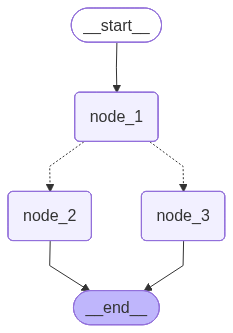

In [ ]:
# StateGraph - agent workflow container
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

# build graph
builder = StateGraph(State)
builder.add_node("node_1",node_1)
builder.add_node("node_2",node_2)
builder.add_node("node_3",node_3)

# logic
builder.add_edge(START, "node_1")
builder.add_conditional_edges("node_1", decide_mood)
builder.add_edge("node_2",END)
builder.add_edge("node_3",END)

# add
graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))


In [19]:
graph.invoke({"graph_state" : "Hi, this is Lance."})

---Node 1---
Hi, this is Lance. I am
---Node 2---


{'graph_state': 'Hi, this is Lance. I am happy!'}

## First Agent - Spam detector
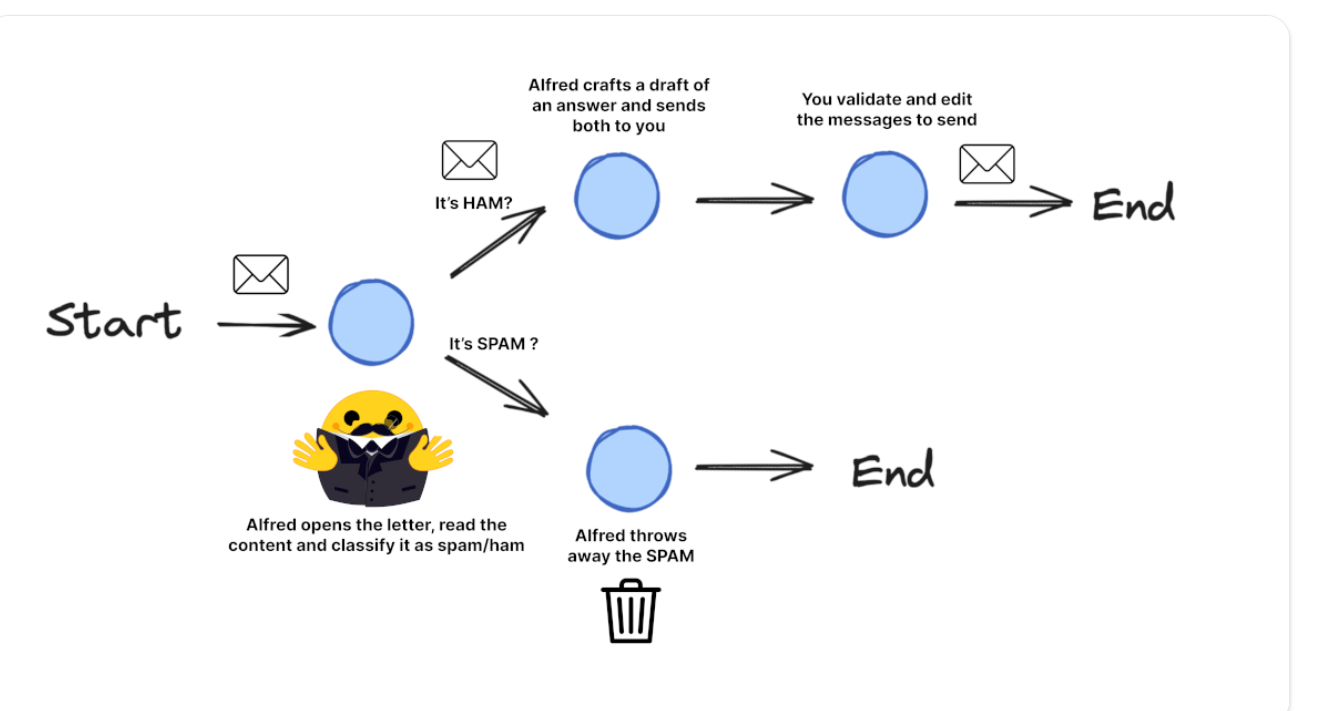
<!-- 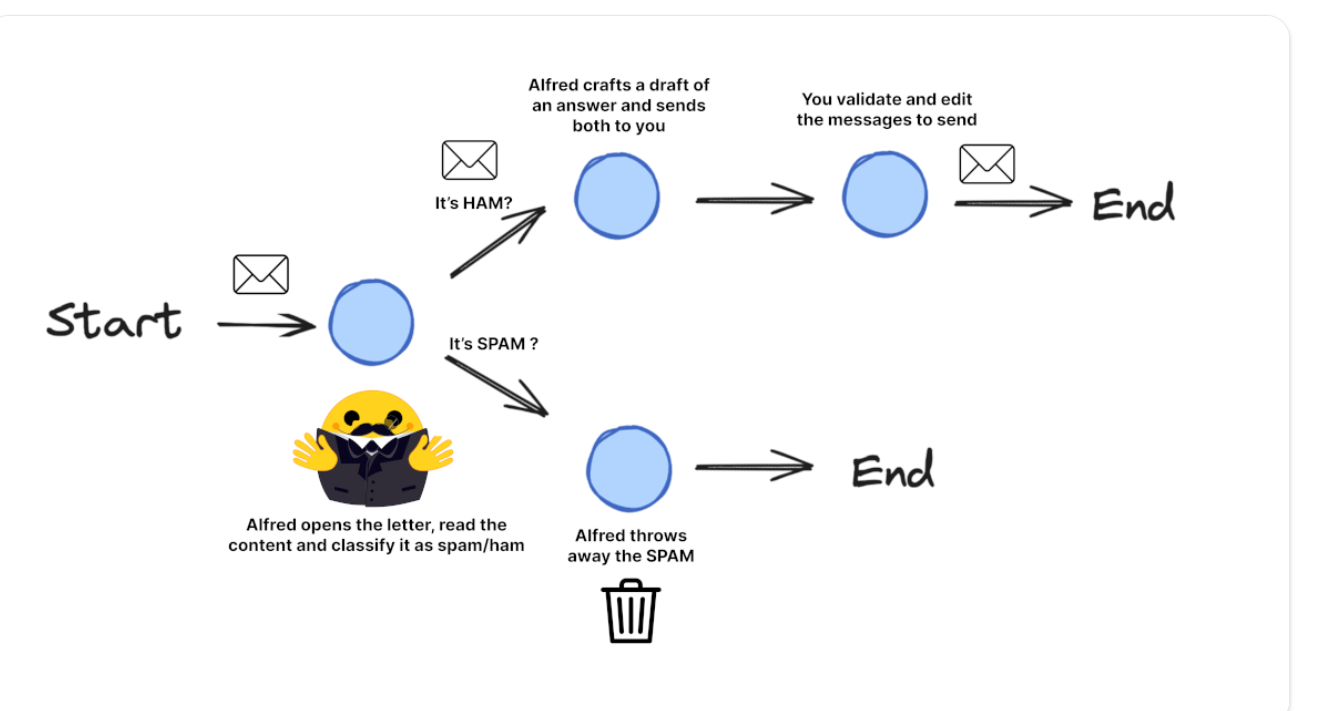 -->
Steps:
1. read incoming mails
2. classify : spam / legit
3. draft for legit mails 
4. send info on legit found

In [21]:
from openai import OpenAI
import os
from dotenv import load_dotenv

load_dotenv(".env")
gemini_key = os.environ.get("GEMINI_API_KEYS")

client = OpenAI(
    base_url="https://generativelanguage.googleapis.com/v1beta/openai/",
    api_key=gemini_key
)


In [23]:
# 1st agemt 
import os
from typing import TypedDict, List, Dict, Any, Optional
from langgraph.graph import StateGraph, START, END
# from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage

# define state
class EmailState(TypedDict):
    email: Dict[str, Any]
    email_catagory: Optional[str] #eg: inquiry, comapilnt etc
    spam_reason: Optional[str]
    is_spam: Optional[bool]
    email_draft: Optional[str]
    messages: List[Dict[str, Any]]  # Track conversation with LLM for analysis


In [ ]:
import os
from langchain_google_genai import ChatGoogleGenerativeAI

# Set API key
os.environ["GEMINI_API_KEY"] = os.getenv("GEMINI_API_KEYS")
api_key = os.getenv("GEMINI_API_KEYS")

# Create LLM class
llm = ChatGoogleGenerativeAI(
    model= "gemini-3-flash-preview",
    temperature=1.0,
    max_retries=2,
    google_api_key=api_key,
)

# Bind tools to the model
# model = llm.bind_tools([get_weather_forecast])

# Test the model with tools
res=llm.invoke(f"What is climate type of India")

print(res)

content='India is generally classified as having a **Tropical Monsoon Climate**.\n\nHowever, because of its vast size and varied geography, the country experiences a wide range of climatic conditions. According to the **Köppen climate classification system**, India is divided into several sub-types:\n\n### 1. The Dominant Type: Tropical Monsoon ($Am$)\nMost of India is dominated by the monsoon system. This involves a seasonal reversal of winds, bringing heavy rainfall during the summer months (June to September) and a dry period during the winter.\n\n### 2. Major Climate Zones in India\nIndia can be broken down into five major climatic regions:\n\n*   **Tropical Wet (Humid):** Found in the Western Ghats, the Malabar Coast, and parts of Northeast India (Assam and Tripura). These areas experience high temperatures and heavy rainfall throughout the year.\n*   **Tropical Wet and Dry (Savanna):** This covers most of the inland peninsular plateau. It is characterized by very hot summers and 

In [1]:
#  Define Nodes

# Initialize our LLM
# langchain x gemini

import os
from langchain_google_genai import ChatGoogleGenerativeAI


model = ChatGoogleGenerativeAI(
    model= "gemini-3-flash-preview",
    temperature=1.0,
    max_retries=2,
    google_api_key=api_key,
)

# model = ChatOpenAI(temperature=0)
# model = client

def read_email(state: EmailState):
    """Alfred reads and logs the incoming email"""
    email = state["email"]
    
    # Here we might do some initial preprocessing
    print(f"Alfred is processing an email from {email['sender']} with subject: {email['subject']}")
    
    # No state changes needed here
    return {}

def classify_email(state: EmailState):
    """Alfred uses an LLM to determine if the email is spam or legitimate"""
    email = state["email"]
    
    # Prepare our prompt for the LLM
    prompt = f"""
    As Alfred the butler, analyze this email and determine if it is spam or legitimate.
    
    Email:
    From: {email['sender']}
    Subject: {email['subject']}
    Body: {email['body']}
    
    First, determine if this email is spam. If it is spam, explain why.
    If it is legitimate, categorize it (inquiry, complaint, thank you, etc.).
    """
    
    # Call the LLM
    messages = [HumanMessage(content=prompt)]
    response = model.invoke(messages)
    
    # Simple logic to parse the response (in a real app, you'd want more robust parsing)
    response_text = response.content.lower()
    
    is_spam = "spam" in response_text and "not spam" not in response_text
    
    # Extract a reason if it's spam
    spam_reason = None
    if is_spam and "reason:" in response_text:
        spam_reason = response_text.split("reason:")[1].strip()
    
    # Determine category if legitimate
    email_category = None
    if not is_spam:
        categories = ["inquiry", "complaint", "thank you", "request", "information"]
        for category in categories:
            if category in response_text:
                email_category = category
                break
    
    # Update messages for tracking
    new_messages = state.get("messages", []) + [
        {"role": "user", "content": prompt},
        {"role": "assistant", "content": response.content}
    ]
    
    # Return state updates
    return {
        "is_spam": is_spam,
        "spam_reason": spam_reason,
        "email_category": email_category,
        "messages": new_messages
    }

def handle_spam(state: EmailState):
    """Alfred discards spam email with a note"""
    print(f"Alfred has marked the email as spam. Reason: {state['spam_reason']}")
    print("The email has been moved to the spam folder.")
    
    # We're done processing this email
    return {}

def draft_response(state: EmailState):
    """Alfred drafts a preliminary response for legitimate emails"""
    email = state["email"]
    category = state["email_category"] or "general"
    
    # Prepare our prompt for the LLM
    prompt = f"""
    As Alfred the butler, draft a polite preliminary response to this email.
    
    Email:
    From: {email['sender']}
    Subject: {email['subject']}
    Body: {email['body']}
    
    This email has been categorized as: {category}
    
    Draft a brief, professional response that Mr. Hugg can review and personalize before sending.
    """
    
    # Call the LLM
    messages = [HumanMessage(content=prompt)]
    response = model.invoke(messages)
    
    # Update messages for tracking
    new_messages = state.get("messages", []) + [
        {"role": "user", "content": prompt},
        {"role": "assistant", "content": response.content}
    ]
    
    # Return state updates
    return {
        "email_draft": response.content,
        "messages": new_messages
    }

def notify_mr_hugg(state: EmailState):
    """Alfred notifies Mr. Hugg about the email and presents the draft response"""
    email = state["email"]
    
    print("\n" + "="*50)
    print(f"Sir, you've received an email from {email['sender']}.")
    print(f"Subject: {email['subject']}")
    print(f"Category: {state['email_category']}")
    print("\nI've prepared a draft response for your review:")
    print("-"*50)
    print(state["email_draft"])
    print("="*50 + "\n")
    
    # We're done processing this email
    return {}


NameError: name 'api_key' is not defined

In [37]:

# routing logic
def route_email(state: EmailState) -> str:
    """Determine the next step based on spam classification"""
    if state["is_spam"]:
        return "spam"
    else:
        return "legitimate"

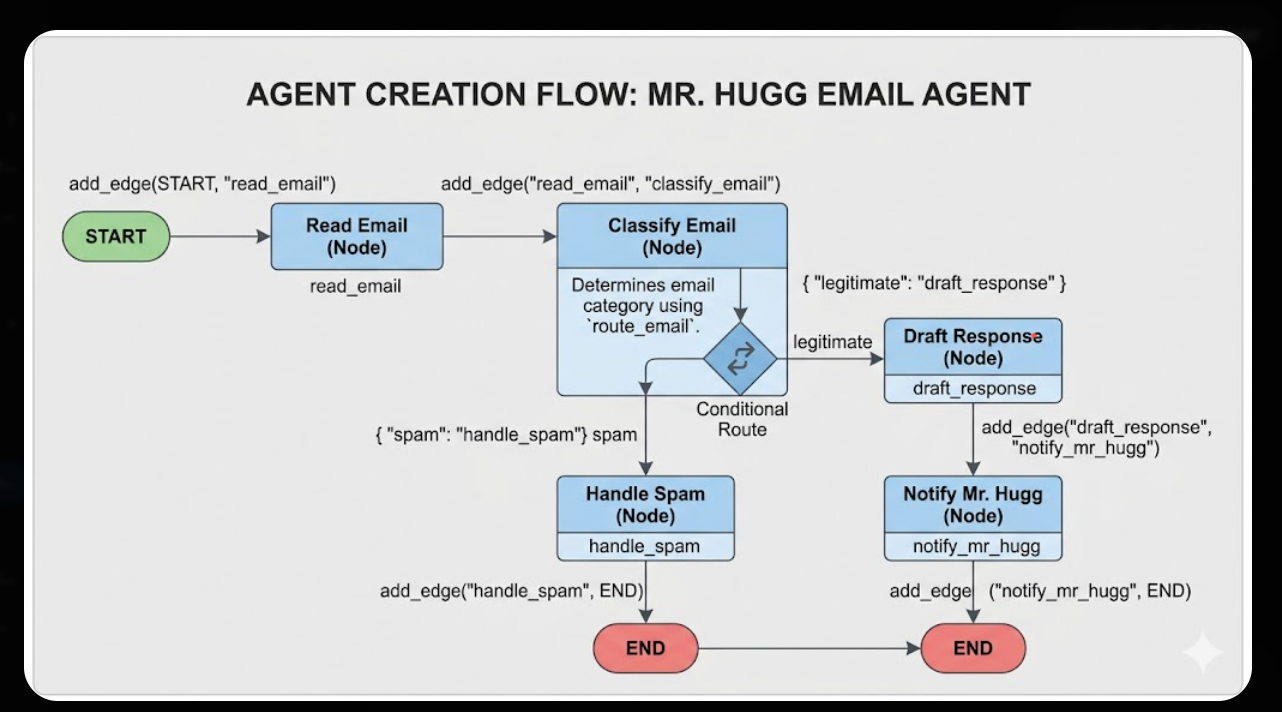

In [38]:
# create agent 
# Create the graph
email_graph = StateGraph(EmailState)

# Add nodes
email_graph.add_node("read_email", read_email)
email_graph.add_node("classify_email", classify_email)
email_graph.add_node("handle_spam", handle_spam)
email_graph.add_node("draft_response", draft_response)
email_graph.add_node("notify_mr_hugg", notify_mr_hugg)

# Start the edges
email_graph.add_edge(START, "read_email")
# Add edges - defining the flow
email_graph.add_edge("read_email", "classify_email")

# Add conditional branching from classify_email
email_graph.add_conditional_edges(
    "classify_email",
    route_email,
    {
        "spam": "handle_spam",
        "legitimate": "draft_response"
    }
)

# Add the final edges
email_graph.add_edge("handle_spam", END)
email_graph.add_edge("draft_response", "notify_mr_hugg")
email_graph.add_edge("notify_mr_hugg", END)

# Compile the graph
compiled_graph = email_graph.compile()

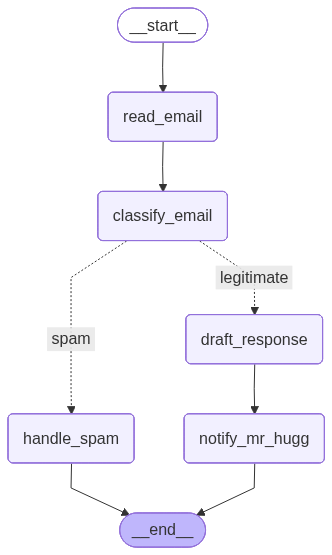

In [27]:
display(Image(compiled_graph.get_graph().draw_mermaid_png()))


In [39]:
# Example legitimate email
legitimate_email = {
    "sender": "john.smith@example.com",
    "subject": "Question about your services",
    "body": "Dear Mr. Hugg, I was referred to you by a colleague and I'm interested in learning more about your consulting services. Could we schedule a call next week? Best regards, John Smith"
}

# Example spam email
spam_email = {
    "sender": "winner@lottery-intl.com",
    "subject": "YOU HAVE WON $5,000,000!!!",
    "body": "CONGRATULATIONS! You have been selected as the winner of our international lottery! To claim your $5,000,000 prize, please send us your bank details and a processing fee of $100."
}

# Process the legitimate email
print("\nProcessing legitimate email...")
legitimate_result = compiled_graph.invoke({
    "email": legitimate_email,
    "is_spam": None,
    "spam_reason": None,
    "email_category": None,
    "email_draft": None,
    "messages": []
})

# Process the spam email
print("\nProcessing spam email...")
spam_result = compiled_graph.invoke({
    "email": spam_email,
    "is_spam": None,
    "spam_reason": None,
    "email_category": None,
    "email_draft": None,
    "messages": []
})


Processing legitimate email...
Alfred is processing an email from john.smith@example.com with subject: Question about your services


AttributeError: 'ChatCompletion' object has no attribute 'content'